# Partition Distribution Analysis

Analyze how Dirichlet partitioning behaves across α and seed for the two FL benchmark tasks.

- **BoolQ**: 50 clients, 2 classes (`super_glue/boolq`)
- **MNLI**:  300 clients, 3 classes (`glue/mnli`, `train` split)
- **α** ∈ {0.5, 2, ∞}  (∞ = IID)
- **seed** ∈ {42, 123, 456}


## Install dependencies

In [7]:
!pip install -q flwr-datasets datasets matplotlib numpy pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [8]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner, IidPartitioner

warnings.filterwarnings("ignore")

OUT_DIR = Path("./result/data_partition")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Configuration

In [9]:
@dataclass
class TaskSpec:
    name: str
    hf_path: str
    hf_subset: str | None
    train_split: str
    num_partitions: int
    num_classes: int
    label_names: list[str]
    min_partition_size: int

TASKS: dict[str, TaskSpec] = {
    # "boolq": TaskSpec(
    #     name="BoolQ",
    #     hf_path="super_glue",
    #     hf_subset="boolq",
    #     train_split="train",
    #     num_partitions=50,
    #     num_classes=2,
    #     label_names=["false", "true"],
    #     min_partition_size=4,
    # ),
    "mnli": TaskSpec(
        name="MNLI",
        hf_path="glue",
        hf_subset="mnli",
        train_split="train",
        num_partitions=300,
        num_classes=3,
        label_names=["entailment", "neutral", "contradiction"],
        min_partition_size=32,
    ),
}

ALPHAS = [0.5, 2, math.inf]   # inf -> IID
SEEDS  = [42, 123, 456]

def alpha_label(a: float) -> str:
    return "inf" if math.isinf(a) else str(a)

## Partitioning helpers

Mirrors `u_flora/dataset.py::_get_partitioner` — Dirichlet for finite α, IID for α=∞.

In [10]:
def make_partitioner(
    num_partitions: int, alpha: float, min_partition_size: int, seed: int
):
    if math.isinf(alpha):
        # IidPartitioner has no seed kwarg; partitioning is deterministic by index.
        return IidPartitioner(num_partitions=num_partitions)
    return DirichletPartitioner(
        num_partitions=num_partitions,
        partition_by="label",
        alpha=alpha,
        seed=seed,
        min_partition_size=min_partition_size,
        self_balancing=True,  # show the raw Dirichlet draw, not a rebalanced one
    )


def collect_partition_matrix(spec: TaskSpec, alpha: float, seed: int) -> np.ndarray:
    """Return an (num_partitions, num_classes) matrix of class counts."""
    fds = FederatedDataset(
        dataset=spec.hf_path,
        subset=spec.hf_subset,
        partitioners={
            spec.train_split: make_partitioner(
                spec.num_partitions, alpha, spec.min_partition_size, seed
            )
        },
    )
    counts = np.zeros((spec.num_partitions, spec.num_classes), dtype=np.int64)
    for pid in range(spec.num_partitions):
        part = fds.load_partition(pid, spec.train_split)
        labels = np.asarray(part["label"]).astype(np.int64)
        labels = labels[labels >= 0]
        bc = np.bincount(labels, minlength=spec.num_classes)
        counts[pid] = bc[: spec.num_classes]
    return counts

## Quantitative metrics

Per (task, α, seed) configuration we record:

- **size_cv**: coefficient of variation of partition sizes (workload imbalance)
- **size_min / size_max**: smallest and largest partition
- **mean_entropy**: average per-client label entropy (in nats); 0 = single-class clients, ln(K) = uniform
- **mean_entropy_norm**: same, normalized by ln(K) so values lie in [0, 1]
- **mean_js_to_global**: mean Jensen–Shannon divergence between each client's label distribution and the global distribution

In [11]:
def entropy(p: np.ndarray, eps: float = 1e-12) -> float:
    p = p[p > 0]
    return float(-(p * np.log(p + eps)).sum())


def js_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = p + eps; q = q + eps
    p = p / p.sum(); q = q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b): return float((a * np.log(a / b)).sum())
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def summarize(counts: np.ndarray) -> dict:
    sizes = counts.sum(axis=1)
    K = counts.shape[1]
    global_dist = counts.sum(axis=0) / counts.sum()

    nz = sizes > 0
    client_dist = np.zeros_like(counts, dtype=float)
    client_dist[nz] = counts[nz] / sizes[nz, None]

    entropies = np.array([entropy(client_dist[i]) for i in range(counts.shape[0])])
    js = np.array([js_divergence(client_dist[i], global_dist) for i in range(counts.shape[0])])

    return {
        "num_clients":         int(counts.shape[0]),
        "total_examples":      int(counts.sum()),
        "size_min":            int(sizes.min()),
        "size_max":            int(sizes.max()),
        "size_mean":           float(sizes.mean()),
        "size_cv":             float(sizes.std() / max(sizes.mean(), 1e-9)),
        "empty_clients":       int((sizes == 0).sum()),
        "mean_entropy":        float(entropies.mean()),
        "mean_entropy_norm":   float(entropies.mean() / math.log(K)),
        "mean_js_to_global":   float(js.mean()),
        "max_js_to_global":    float(js.max()),
    }

## Run all configurations

Caches the count matrices so we can re-plot without re-partitioning.

In [12]:
matrices: dict[tuple[str, float, int], np.ndarray] = {}
summary_rows: list[dict] = []

for task_key, spec in TASKS.items():
    for alpha in ALPHAS:
        for seed in SEEDS:
            tag = f"{task_key} | α={alpha_label(alpha)} | seed={seed}"
            print(f"→ {tag}")
            counts = collect_partition_matrix(spec, alpha, seed)
            matrices[(task_key, alpha, seed)] = counts

            row = {"task": task_key, "alpha": alpha_label(alpha), "seed": seed}
            row.update(summarize(counts))
            summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

→ mnli | α=0.5 | seed=42
→ mnli | α=0.5 | seed=123
→ mnli | α=0.5 | seed=456
→ mnli | α=2 | seed=42
→ mnli | α=2 | seed=123
→ mnli | α=2 | seed=456
→ mnli | α=inf | seed=42
→ mnli | α=inf | seed=123
→ mnli | α=inf | seed=456


,task,alpha,seed,num_clients,total_examples,size_min,size_max,size_mean,size_cv,empty_clients,mean_entropy,mean_entropy_norm,mean_js_to_global,max_js_to_global
0,mnli,0.5,42,300,392702,35,5093,1309.006667,0.729966,0,0.575215,0.523584,0.147833,0.318260
1,mnli,0.5,123,300,392702,34,7682,1309.006667,0.789375,0,0.580248,0.528164,0.145879,0.318260
2,mnli,0.5,456,300,392702,37,5084,1309.006667,0.675496,0,0.563699,0.513101,0.151242,0.318260
3,mnli,2,42,300,392702,304,3450,1309.006667,0.360027,0,0.884125,0.804765,0.059882,0.318260
4,mnli,2,123,300,392702,381,2850,1309.006667,0.349017,0,0.895482,0.815103,0.057091,0.318260
5,mnli,2,456,300,392702,257,3593,1309.006667,0.353607,0,0.869568,0.791514,0.063545,0.318260
6,mnli,inf,42,300,392702,1309,1310,1309.006667,0.000062,0,1.097815,0.999274,0.000199,0.001579
7,mnli,inf,123,300,392702,1309,1310,1309.006667,0.000062,0,1.097815,0.999274,0.000199,0.001579
8,mnli,inf,456,300,392702,1309,1310,1309.006667,0.000062,0,1.097815,0.999274,0.000199,0.001579


## Aggregate table (mean across seeds)

In [13]:
agg_cols = ["size_cv", "size_min", "size_max", "mean_entropy_norm", "mean_js_to_global", "empty_clients"]
agg = (
    summary_df.groupby(["task", "alpha"])[agg_cols]
    .agg(["mean", "std"])
    .round(4)
)
agg

size_cv           size_min            size_max             \
              mean     std       mean      std       mean        std   
task alpha                                                             
mnli 0.5    0.7316  0.0570    35.3333   1.5275  5953.0000  1497.3647   
     2      0.3542  0.0055   314.0000  62.6019  3297.6667   394.2288   
     inf    0.0001  0.0000  1309.0000   0.0000  1310.0000     0.0000   

           mean_entropy_norm         mean_js_to_global         empty_clients  \
                        mean     std              mean     std          mean   
task alpha                                                                     
mnli 0.5              0.5216  0.0077            0.1483  0.0027           0.0   
     2                0.8038  0.0118            0.0602  0.0032           0.0   
     inf              0.9993  0.0000            0.0002  0.0000           0.0   

                 
            std  
task alpha       
mnli 0.5    0.0  
     2      0.0  
     inf    0.0

## Visualization 1 — Per-client class proportions (stacked bars)

Each subplot is one (α, seed). Within a subplot, the x-axis is `client_id` sorted by majority-class share so heterogeneity is visually obvious. IID (α=∞) should look uniform; small α should show extreme spikes.

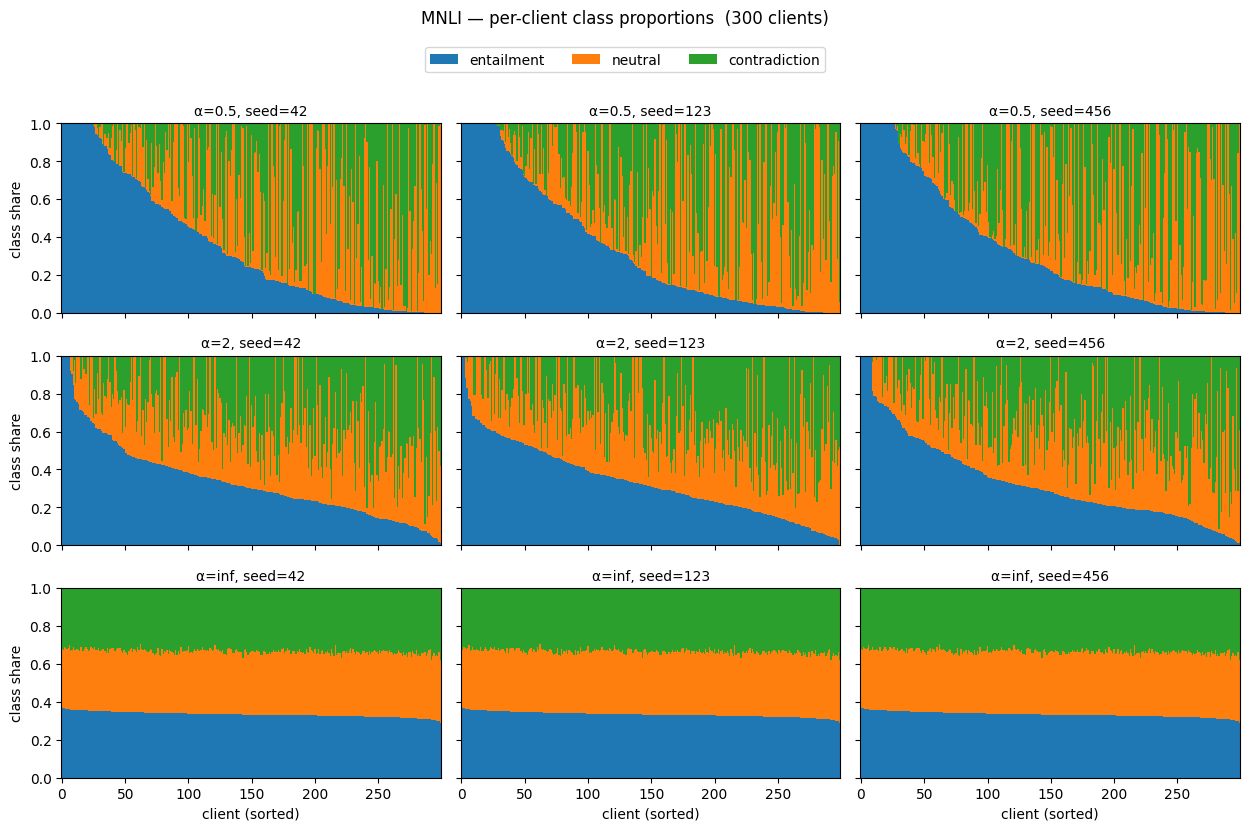

saved: result\data_partition\stacked_mnli.png


In [15]:
def plot_stacked(task_key: str):
    spec = TASKS[task_key]
    fig, axes = plt.subplots(
        len(ALPHAS), len(SEEDS),
        figsize=(4.2 * len(SEEDS), 2.6 * len(ALPHAS)),
        sharex=True, sharey=True,
    )
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(spec.num_classes)]

    for i, alpha in enumerate(ALPHAS):
        for j, seed in enumerate(SEEDS):
            ax = axes[i, j]
            counts = matrices[(task_key, alpha, seed)]
            sizes = counts.sum(axis=1, keepdims=True).clip(min=1)
            props = counts / sizes
            order = np.argsort(-props[:, 0])
            props = props[order]

            x = np.arange(props.shape[0])
            bottom = np.zeros(props.shape[0])
            for c in range(spec.num_classes):
                ax.bar(
                    x, props[:, c], bottom=bottom,
                    color=colors[c], width=1.0,
                    label=spec.label_names[c] if (i == 0 and j == 0) else None,
                )
                bottom += props[:, c]

            ax.set_title(f"α={alpha_label(alpha)}, seed={seed}", fontsize=10)
            ax.set_ylim(0, 1)
            ax.set_xlim(-0.5, spec.num_partitions - 0.5)
            if j == 0:
                ax.set_ylabel("class share")
            if i == len(ALPHAS) - 1:
                ax.set_xlabel("client (sorted)")

    fig.legend(loc="upper center", ncol=spec.num_classes, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{spec.name} — per-client class proportions  ({spec.num_partitions} clients)", y=1.06, fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / f"stacked_{task_key}.png"
    # plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved: {out}")

# plot_stacked("boolq")
plot_stacked("mnli")

## Visualization 2 — Partition size distribution

Workload imbalance independent of label skew. Small α produces a few large + many tiny partitions.

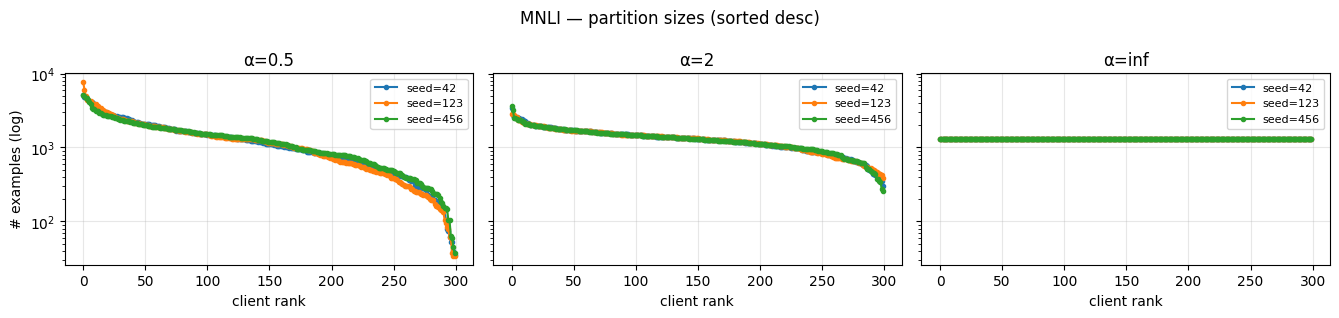

saved: result\data_partition\sizes_mnli.png


In [17]:
def plot_sizes(task_key: str):
    spec = TASKS[task_key]
    fig, axes = plt.subplots(1, len(ALPHAS), figsize=(4.5 * len(ALPHAS), 3.2), sharey=True)
    for i, alpha in enumerate(ALPHAS):
        ax = axes[i]
        for seed in SEEDS:
            sizes = matrices[(task_key, alpha, seed)].sum(axis=1)
            sizes_sorted = np.sort(sizes)[::-1]
            ax.plot(np.arange(len(sizes_sorted)), sizes_sorted,
                    marker="o", ms=3, label=f"seed={seed}")
        ax.set_title(f"α={alpha_label(alpha)}")
        ax.set_xlabel("client rank")
        ax.grid(True, alpha=0.3)
        ax.set_yscale("log")
        if i == 0:
            ax.set_ylabel("# examples (log)")
        ax.legend(fontsize=8)
    fig.suptitle(f"{spec.name} — partition sizes (sorted desc)", fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / f"sizes_{task_key}.png"
    # plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved: {out}")

# plot_sizes("boolq")
plot_sizes("mnli")

## Visualization 3 — Heterogeneity metrics across α

Bars are seed means; error bars are min/max across the three seeds — shows seed-to-seed variability of each α regime.

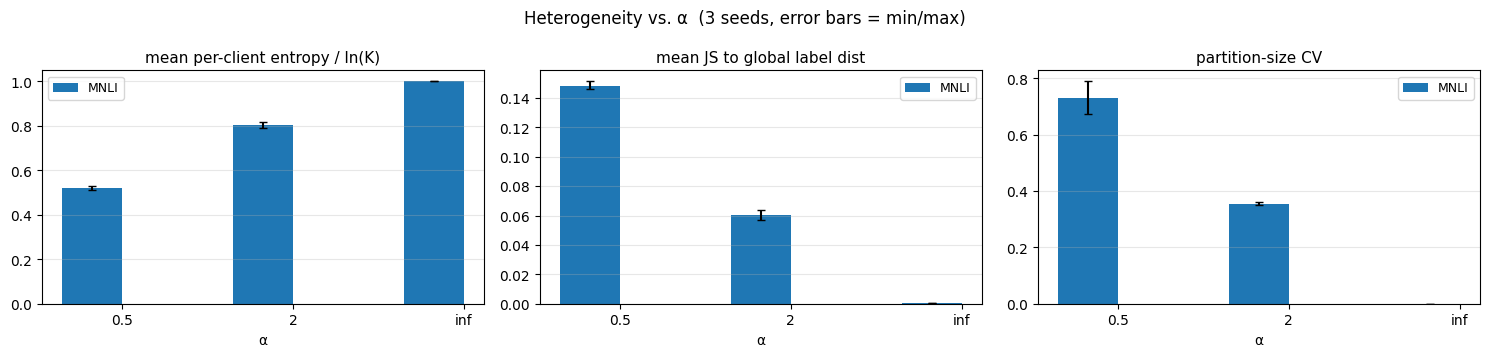

saved: result\data_partition\metrics_vs_alpha.png


In [18]:
def plot_metric_bars():
    metrics = [
        ("mean_entropy_norm", "mean per-client entropy / ln(K)"),
        ("mean_js_to_global", "mean JS to global label dist"),
        ("size_cv",           "partition-size CV"),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 3.6))
    width = 0.35
    x = np.arange(len(ALPHAS))

    for ax, (col, title) in zip(axes, metrics):
        for k, task_key in enumerate(TASKS):
            sub = summary_df[summary_df.task == task_key]
            means = [sub[sub.alpha == alpha_label(a)][col].mean() for a in ALPHAS]
            mins  = [sub[sub.alpha == alpha_label(a)][col].min()  for a in ALPHAS]
            maxs  = [sub[sub.alpha == alpha_label(a)][col].max()  for a in ALPHAS]
            err = np.array([
                [m - mn for m, mn in zip(means, mins)],
                [mx - m for m, mx in zip(means, maxs)],
            ])
            ax.bar(x + (k - 0.5) * width, means, width=width,
                   yerr=err, capsize=3, label=TASKS[task_key].name)
        ax.set_xticks(x)
        ax.set_xticklabels([alpha_label(a) for a in ALPHAS])
        ax.set_xlabel("α")
        ax.set_title(title, fontsize=11)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=9)
    fig.suptitle("Heterogeneity vs. α  (3 seeds, error bars = min/max)", fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / "metrics_vs_alpha.png"
    # plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved: {out}")

plot_metric_bars()

## Save summary

In [19]:
# csv_path  = OUT_DIR / "partition_summary.csv"
# json_path = OUT_DIR / "partition_summary.json"
# summary_df.to_csv(csv_path, index=False)
# json_path.write_text(json.dumps(summary_rows, indent=2))
# print(f"saved: {csv_path}")
# print(f"saved: {json_path}")

# np_path = OUT_DIR / "partition_counts.npz"
# np.savez(
#     np_path,
#     **{f"{t}__a{alpha_label(a)}__s{s}": m for (t, a, s), m in matrices.items()},
# )
# print(f"saved: {np_path}")

## Interpretation guide

- **α = 2** → high label skew: many clients are near-single-class, `mean_entropy_norm` is low, `mean_js_to_global` is high, partition sizes are wildly uneven (`size_cv` large, possibly empty clients).
- **α = 8** → moderate skew: the standard FL benchmark setting. Each client sees most classes but with non-uniform proportions.
- **α = ∞** → IID: `mean_entropy_norm ≈ 1`, `mean_js_to_global ≈ 0`, `size_cv` only reflects integer-rounding.

Seed variance is highest at α=0.1 — this is why the FL benchmark sweeps three seeds rather than one.

## Thesis figure: MNLI partition distribution

Two-row figure for Section 3.4 of the thesis. Run after the main partitioning loop (Cell 12).
Output: `result/data_partition/thesis_mnli_partition.[png|pdf]`

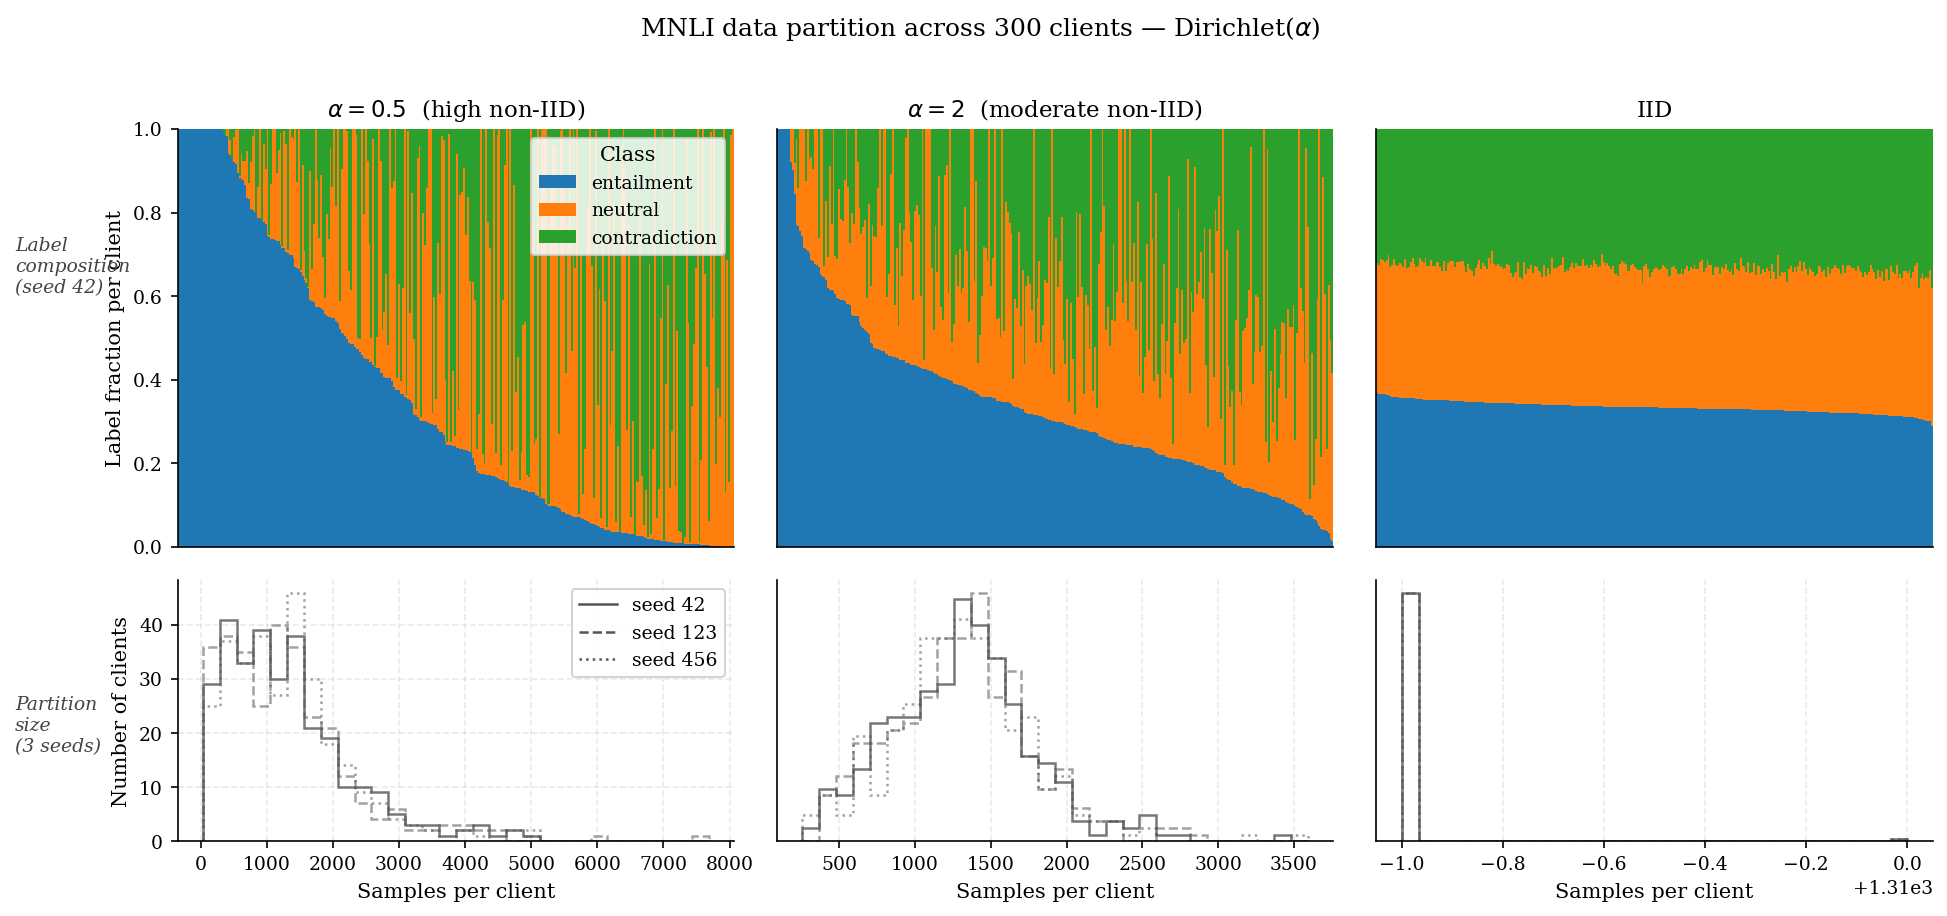

Saved → result\data_partition\thesis_mnli_partition.png
Saved → result\data_partition\thesis_mnli_partition.pdf

Copy to thesis: cp result\data_partition\thesis_mnli_partition.pdf <your-thesis-root>/assets/figures/data_distribution.pdf


In [20]:
# ── Thesis figure: MNLI partition distribution ──────────────────────────────
#
# 2-row × 3-column layout (one column per α condition).
#   Row 1 — Label composition (seed=42, clients sorted by majority-class share)
#   Row 2 — Partition-size distribution (all 3 seeds, overlaid histograms)
#
# Save → OUT_DIR / "thesis_mnli_partition.[png|pdf]"
# Copy the output to your thesis assets/figures/ directory.

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TASK_KEY   = "mnli"
LABEL_SEED = 42                     # seed used for the label-composition row
ALPHA_ORDER = [0.5, 2, math.inf]    # left → right: high non-IID → IID
ALPHA_TITLES = {
    0.5:       r"$\alpha = 0.5$  (high non-IID)",
    2:         r"$\alpha = 2$  (moderate non-IID)",
    math.inf:  "IID",
}
CLASS_LABELS = TASKS[TASK_KEY].label_names          # ["entailment", "neutral", "contradiction"]
N_CLASSES    = TASKS[TASK_KEY].num_classes
N_CLIENTS    = TASKS[TASK_KEY].num_partitions        # 300

# ── Thesis style (mirrors mnli_plotting_v2 rcParams) ────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "serif",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
})

CLASS_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]   # entailment / neutral / contradiction
SEED_STYLES  = {42: ("-",  0.80), 123: ("--", 0.55), 456: (":", 0.55)}

fig, axes = plt.subplots(
    2, len(ALPHA_ORDER),
    figsize=(13, 6),
    gridspec_kw={"height_ratios": [1.6, 1]},
)

for col, alpha in enumerate(ALPHA_ORDER):

    # ── Row 1: label composition ─────────────────────────────────────────────
    ax1 = axes[0, col]
    counts = matrices[(TASK_KEY, alpha, LABEL_SEED)]      # (N, C)
    sizes  = counts.sum(axis=1, keepdims=True).clip(min=1)
    props  = counts / sizes                                # label fractions

    # Sort clients so highest entailment-share is on the left
    order = np.argsort(-props[:, 0])
    props = props[order]

    x      = np.arange(N_CLIENTS)
    bottom = np.zeros(N_CLIENTS)
    for c in range(N_CLASSES):
        ax1.bar(x, props[:, c], bottom=bottom,
                color=CLASS_COLORS[c], width=1.0, linewidth=0,
                label=CLASS_LABELS[c] if col == 0 else None)
        bottom += props[:, c]

    ax1.set_title(ALPHA_TITLES[alpha], pad=6)
    ax1.set_xlim(-0.5, N_CLIENTS - 0.5)
    ax1.set_ylim(0, 1.0)
    ax1.set_xticks([])
    ax1.grid(False)
    if col == 0:
        ax1.set_ylabel("Label fraction per client")
    else:
        ax1.set_yticks([])

    # ── Row 2: partition-size histogram ──────────────────────────────────────
    ax2 = axes[1, col]

    all_sizes = np.concatenate([
        matrices[(TASK_KEY, alpha, s)].sum(axis=1) for s in SEEDS
    ])
    bin_edges = np.histogram_bin_edges(all_sizes, bins=30)

    for seed in SEEDS:
        sz = matrices[(TASK_KEY, alpha, seed)].sum(axis=1)
        ls, alp = SEED_STYLES[seed]
        ax2.hist(sz, bins=bin_edges, histtype="step",
                 linewidth=1.2, linestyle=ls, alpha=alp,
                 color="#555555",
                 label=f"seed {seed}" if col == 0 else None)

    ax2.set_xlabel("Samples per client")
    if col == 0:
        ax2.set_ylabel("Number of clients")
    else:
        ax2.set_yticks([])

# ── Shared legends ───────────────────────────────────────────────────────────
# Label-composition legend (top-left panel)
handles_cls = [
    mpatches.Patch(facecolor=CLASS_COLORS[c], label=CLASS_LABELS[c])
    for c in range(N_CLASSES)
]
axes[0, 0].legend(handles=handles_cls, loc="upper right",
                  framealpha=0.85, fontsize=9, title="Class")

# Seed legend (bottom-left panel)
from matplotlib.lines import Line2D
handles_seed = [
    Line2D([0], [0], color="#555555", linestyle=ls, linewidth=1.2,
           alpha=1.0, label=f"seed {s}")
    for s, (ls, _) in SEED_STYLES.items()
]
axes[1, 0].legend(handles=handles_seed, loc="upper right",
                  framealpha=0.85, fontsize=9)

# ── Row labels ───────────────────────────────────────────────────────────────
fig.text(0.005, 0.73, "Label\ncomposition\n(seed 42)", ha="left", va="center",
         fontsize=9, color="#444444", style="italic")
fig.text(0.005, 0.22, "Partition\nsize\n(3 seeds)", ha="left", va="center",
         fontsize=9, color="#444444", style="italic")

fig.suptitle(
    r"MNLI data partition across 300 clients — Dirichlet($\alpha$)",
    y=1.01, fontsize=12,
)
plt.tight_layout(rect=[0.04, 0, 1, 1])

# ── Save ─────────────────────────────────────────────────────────────────────
out_png = OUT_DIR / "thesis_mnli_partition.png"
out_pdf = OUT_DIR / "thesis_mnli_partition.pdf"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved → {out_png}")
print(f"Saved → {out_pdf}")
print(f"\nCopy to thesis: cp {out_pdf} <your-thesis-root>/assets/figures/data_distribution.pdf")
